Successfully loaded config file: C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\config.json
Changed attributes: ocr_credits, exposure_time, image_rotation, brightness_scale_factor, skincolor_open_radius, skincolor_close_radius, linestring_resample_distance, linestring_smoothing, position_queue_length, max_cursor_mean_deviation_for_snapshot, distance_from_cursor_for_snapshot_reset, projection_delay_ms, cursor_circle_start_radius_mm, cursor_size, cursor_color, cursor_circle_thickness, standstill_color, cutout_size_as_multiple_of_tip_to_joint, fingermark_down_move_mm, finger_cursor_position_smoothing, finger_angle_smoothing, project_on_finger, paper_gaussian, paper_min_brightness, paper_max_saturation, paper_text_font_size, fingernail_center_shift_factor, mediapipe_use_complex_model, min_mediapipe_confidence, bounding_box_color_untranslated, bounding_box_color, detected_text_bounding_box_anchor, detected_text_font_size, show_confidence_score, include_symbols, camera_bound

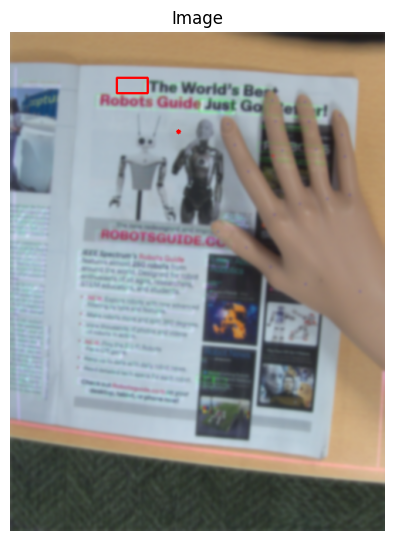

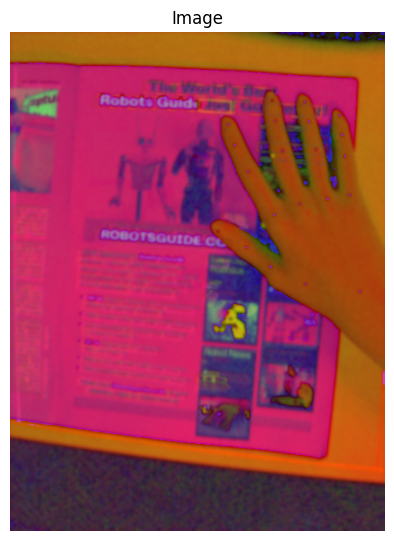

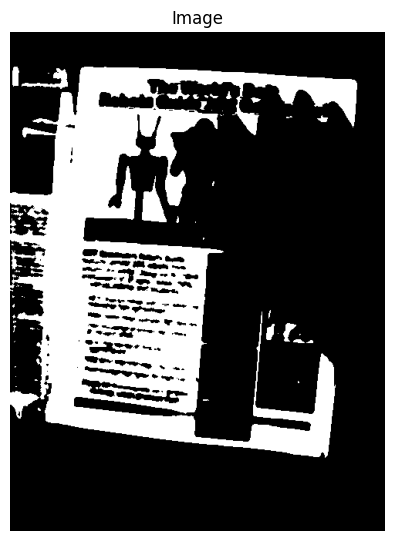

In [5]:
from collections import deque
import math
import sys
import os

from matplotlib import pyplot as plt


sys.path.append(os.path.abspath(".."))
import matlike_utils
from config import Config
from automatic_config_reloader import AutomaticConfigReloader
from enums import *
import drawing
from drawing import *
import plotting
import whitespace_finder

config_loader = AutomaticConfigReloader(
    r"C:\Users\sens\Desktop\FingernailProjection\FingernailProjection\config.json", Config
)
config: Config = config_loader.config

from collections import deque
import math
import sys
import os


sys.path.append(os.path.abspath(".."))


from enums import *


import drawing
from drawing import *
import plotting


def find_white_space_topleft(
    binary_image: np.ndarray, rectangle: tuple[int, int]
) -> tuple[int, int] | None:
    """
    Finds the first available white space in the mask using an integral image for efficiency.
    Returns the top-left (x, y) position or None if no space is found.
    """
    image_height, image_width = binary_image.shape
    rect_width, rect_height = rectangle

    # Compute the integral image
    integral_image = cv2.integral(binary_image)

    for y in range(image_height - rect_height + 1):
        for x in range(image_width - rect_width + 1):
            # Sum of pixels in the window using the integral image
            total_white = (
                integral_image[y + rect_height, x + rect_width]
                - integral_image[y, x + rect_width]
                - integral_image[y + rect_height, x]
                + integral_image[y, x]
            )

            # If the window is fully white, return position
            if total_white == rect_width * rect_height:
                return (x, y)

    return None  # No suitable space found


def find_white_space_topleft_spiral(
    binary_image: np.ndarray, rectangle: tuple[int, int], start: tuple[int, int], step: int = 1
) -> tuple[int, int] | None:
    """
    Finds the first available white space in the mask, expanding outward in a spiral from (start_x, start_y).
    Returns the top-left (x, y) position or None if no space is found.
    """
    image_height, image_width = binary_image.shape
    rect_width, rect_height = rectangle
    start_x, start_y = start

    # Compute the integral image
    integral_image = cv2.integral(binary_image)

    # Spiral search setup
    x, y = start_x, start_y
    dx, dy = step, 0  # Initial movement direction (right)
    segment_length = 1  # Steps in the current direction before turning
    steps_taken = 0  # Steps in the current segment
    segment_passes = 0  # Number of times segment length has been used (every 2 times, it increases)

    while 0 <= x < image_width and 0 <= y < image_height:
        # Check if the rectangle fits inside the image bounds
        if x + rect_width <= image_width and y + rect_height <= image_height:
            # Compute sum of pixels in the window using the integral image
            total_white = (
                integral_image[y + rect_height, x + rect_width]
                - integral_image[y, x + rect_width]
                - integral_image[y + rect_height, x]
                + integral_image[y, x]
            )

            # If the window is fully white, return position
            if total_white == rect_width * rect_height:
                return (x, y)

        # Move in the current direction
        x += dx
        y += dy
        steps_taken += 1

        # If we've reached the end of the current segment length
        if steps_taken == segment_length:
            steps_taken = 0  # Reset step counter
            dx, dy = -dy, dx  # Rotate direction (right → down → left → up)
            segment_passes += 1  # Count how many segments we've completed

            # Every two turns, increase the segment length
            if segment_passes % 2 == 0:
                segment_length += step

    return None  # No suitable space found


width = 40
height = 20

# Apply gaussian blur
recorded_image_bgr = cv2.imread(r"C:\Users\sens\Desktop\FingernailProjection\Doku\ForMask.jpg")
small_image = matlike_utils.scale_image(
    recorded_image_bgr, config.paper_reduction_factor, matlike_utils.ScalingMode.Area
)
image = matlike_utils.apply_gaussian(small_image, config.paper_gaussian)
# Define threshold for white paper (low saturation, high brightness)
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(
    hsv_image,
    (0, 0, config.paper_min_brightness),
    (180, config.paper_max_saturation, 255),
)
binary_mask = (mask == 255).astype(np.uint8)

image_height, image_width = binary_mask.shape

start_position = (int(image_width * 0.45), int(image_height * 0.2))
drawing.point(image, start_position, RED, 3)

if topleft := whitespace_finder.find_white_space_topleft_spiral(
    binary_mask, (width, height), start_position
):
    print("topleft = ", topleft)
    drawing.rect(image, topleft, (topleft[0] + width, topleft[1] + height), RED, 2)


plotting.plot_bgr_image(image)
plotting.plot_bgr_image(hsv_image)
plotting.plot_bgr_image(cv2.cvtColor(255 * binary_mask, cv2.COLOR_GRAY2BGR))
# plotting.plot_rgb_images_horizontally([mask, image])